# Módulo 2 — Modelo de Regresión
## Predicción del costo de embarques

---

### Objetivo de negocio
Construir un modelo que **prediga el costo esperado de un embarque** a partir de sus
características (distancia, peso, modo de transporte, carrier, etc.). El propósito no es
solo predecir, sino **detectar embarques cuyo costo real se desvía significativamente
del costo esperado** — es decir, identificar sobrecostos y posibles anomalías de facturación.

### Pregunta que responde
> *"Dado un embarque con ciertas características, ¿cuánto debería costar? Y si el costo
> real es muy superior a lo esperado, ¿por qué?"*

### Datos utilizados
- **Fuente:** `02_shipments_limpio.csv` (219,120 embarques)
- **Variable objetivo (target):** `total_cost_usd`
- **Variables predictoras (features):** características físicas y operativas del embarque

### Metodología
Se entrenarán y compararán dos modelos:
1. **Regresión Lineal:** modelo base (*baseline*) simple e interpretable, sirve como
   punto de referencia mínimo.
2. **Random Forest:** modelo de ensamble más potente, capaz de capturar relaciones
   no lineales e interacciones entre variables.

Se comparan porque **siempre debe existir un baseline**: si un modelo complejo no supera
a uno simple, no vale la pena su complejidad. Esta es una práctica estándar en ciencia
de datos.

### Métricas de evaluación
- **MAE (Error Absoluto Medio):** en promedio, ¿por cuántos dólares se equivoca el modelo?
- **RMSE (Raíz del Error Cuadrático Medio):** penaliza más los errores grandes.
- **R² (Coeficiente de determinación):** ¿qué porcentaje de la variación del costo
  explica el modelo? (1.0 = perfecto, 0 = inútil).

### Aplicación de negocio
Un modelo confiable permite: (1) detectar cobros anómalos comparando costo real vs.
predicho, (2) cotizar embarques nuevos, y (3) auditar facturas de carriers de forma
sistemática.

---

## 1. Carga de datos y selección de variables

Cargamos el dataset y seleccionamos cuidadosamente las variables predictoras.
Esta selección es una **decisión crítica** que requiere criterio de negocio, no solo técnico.

### Regla fundamental: evitar el *data leakage* (fuga de información)

El **data leakage** ocurre cuando incluimos como predictoras variables que en la
realidad **no conoceríamos antes de que el embarque ocurra**, o que son componentes
directos del costo que intentamos predecir. Incluirlas daría un modelo "tramposo":
tendría métricas excelentes en pruebas, pero sería inútil en la práctica.

**Variables que DEBEMOS EXCLUIR y por qué:**
- `linehaul_cost_usd`, `fuel_surcharge_usd`, `accessorial_usd`, `customs_fee_usd`,
  `detention_usd`: son los **componentes que suman el `total_cost_usd`**. Usarlos sería
  como predecir el total de una factura teniendo ya sus renglones — trivial e inútil.
- `invoice_amount_usd`, `invoice_variance_usd`: derivadas del costo final, no se conocen
  de antemano.
- `costo_por_kg`, `costo_por_km`: calculadas a partir del costo total (leakage directo).

**Variables que SÍ usaremos (conocidas antes del embarque):**
- Físicas: `weight_kg`, `volume_cbm`, `chargeable_weight_kg`, `pallets`, `distance_km`
- Operativas: `mode`, `service_level`, `carrier_id`, `cross_border_flag`, `business_unit`,
  `customer_segment`, `incoterm`

Estas son características que **sí conocemos al momento de planear un embarque**, por lo
que el modelo sería genuinamente útil para cotizar y auditar.

In [1]:
# ============================================================
# MÓDULO 2: REGRESIÓN — Predicción de costo de embarques
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configuración visual
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_palette('deep')

# Cargar datos
df = pd.read_csv('../data/processed/02_shipments_limpio.csv')
print(f"✓ Datos cargados: {df.shape[0]:,} embarques")

# ---- Selección de variables (evitando data leakage) ----

# Variables numéricas predictoras (conocidas antes del embarque)
features_num = ['weight_kg', 'volume_cbm', 'chargeable_weight_kg',
                'pallets', 'distance_km']

# Variables categóricas predictoras
features_cat = ['mode', 'service_level', 'carrier_id', 'cross_border_flag',
                'business_unit', 'customer_segment', 'incoterm']

# Variable objetivo
target = 'total_cost_usd'

# Armar el conjunto de trabajo
X = df[features_num + features_cat].copy()
y = df[target].copy()

print(f"✓ Variables predictoras: {len(features_num)} numéricas + {len(features_cat)} categóricas")
print(f"✓ Variable objetivo: {target}")
print(f"✓ Forma de X: {X.shape}")
print()
print("Vista previa de las variables predictoras:")
print(X.head())

✓ Datos cargados: 219,120 embarques
✓ Variables predictoras: 5 numéricas + 7 categóricas
✓ Variable objetivo: total_cost_usd
✓ Forma de X: (219120, 12)

Vista previa de las variables predictoras:
   weight_kg  volume_cbm  chargeable_weight_kg  pallets  distance_km    mode  \
0       18.1       0.064                  18.1        0       2700.1  Parcel   
1    11576.0     120.984               11576.0       87       1177.4      TL   
2     8602.1      32.269                8602.1       24       1473.7      TL   
3    13231.4     115.844               13231.4       83       2157.7      TL   
4      667.5       3.971                 667.5        3       1502.3     LTL   

  service_level carrier_id  cross_border_flag business_unit customer_segment  \
0        Ground       C016                  0        Energy              OEM   
1      Standard       C006                  0        Energy              OEM   
2      Standard       C004                  0    Industrial      Aftermarket   
3  

## 2. Preparación: división train/test y codificación

### División entrenamiento / prueba (train/test split)
Separamos los datos en dos conjuntos:
- **Entrenamiento (80%):** el modelo aprende de aquí.
- **Prueba (20%):** datos que el modelo NUNCA vio, para evaluar su desempeño real.

**¿Por qué separar?** Si evaluáramos el modelo con los mismos datos con que aprendió,
las métricas serían engañosamente buenas (como calificar un examen con las respuestas
a la vista). La prueba con datos nuevos mide la capacidad real de **generalización**.

Usamos `random_state=42` para que la división sea **reproducible**: cualquiera que
corra este notebook obtendrá exactamente los mismos resultados.

### Codificación de variables categóricas (One-Hot Encoding)
Los modelos matemáticos solo entienden números, no texto como "TL" o "Ground".
El **One-Hot Encoding** convierte cada categoría en columnas binarias (0/1). Por ejemplo,
la columna `mode` con valores {Parcel, TL, LTL...} se convierte en varias columnas:
`mode_Parcel`, `mode_TL`, `mode_LTL`, cada una con 1 si aplica y 0 si no.

Usamos un **ColumnTransformer** dentro de un **Pipeline** para que la codificación se
aplique de forma consistente y automática, sin riesgo de errores manuales. Esta es la
forma profesional de hacerlo en scikit-learn.

In [2]:
    # ============================================================
# División train/test y configuración del preprocesamiento
# ============================================================

# Separar en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42   # semilla para reproducibilidad
)

print(f"✓ Entrenamiento: {X_train.shape[0]:,} embarques")
print(f"✓ Prueba:        {X_test.shape[0]:,} embarques")
print()

# Configurar el preprocesamiento:
# - Las numéricas pasan sin cambios ('passthrough')
# - Las categóricas se codifican con One-Hot Encoding
preprocesador = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', features_num),
        ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat)
    ]
)

print("✓ Preprocesador configurado:")
print(f"  - {len(features_num)} variables numéricas → sin transformar")
print(f"  - {len(features_cat)} variables categóricas → One-Hot Encoding")
print()
print("handle_unknown='ignore': si en producción aparece una categoría nueva")
print("(ej. un carrier no visto), el modelo no falla, solo la ignora.")

✓ Entrenamiento: 175,296 embarques
✓ Prueba:        43,824 embarques

✓ Preprocesador configurado:
  - 5 variables numéricas → sin transformar
  - 7 variables categóricas → One-Hot Encoding

handle_unknown='ignore': si en producción aparece una categoría nueva
(ej. un carrier no visto), el modelo no falla, solo la ignora.


## 3. Modelo baseline: Regresión Lineal

Entrenamos primero una **Regresión Lineal** como punto de referencia (*baseline*).

**¿Por qué empezar con el modelo más simple?**
Un baseline establece el "mínimo a superar". Si luego un modelo complejo (Random Forest)
no mejora significativamente sobre esta regresión simple, entonces la complejidad extra
no se justifica. Empezar simple es una disciplina que evita sobre-ingeniería.

La regresión lineal asume que el costo es una **combinación lineal** de las variables
(ej. "cada km extra suma X dólares, cada kg suma Y dólares"). Es interpretable pero
limitada: no captura relaciones no lineales ni interacciones complejas.

Usamos un **Pipeline** que une el preprocesamiento (codificación) con el modelo, para
que todo el flujo sea automático y reproducible.

In [3]:
    # ============================================================
# Modelo 1: Regresión Lineal (baseline)
# ============================================================

# Pipeline: preprocesamiento + modelo, todo en un solo objeto
modelo_lineal = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('regresor', LinearRegression())
])

# Entrenar
print("Entrenando Regresión Lineal...")
modelo_lineal.fit(X_train, y_train)

# Predecir sobre el conjunto de prueba (datos nunca vistos)
pred_lineal = modelo_lineal.predict(X_test)

# Evaluar con las tres métricas
mae_lineal = mean_absolute_error(y_test, pred_lineal)
rmse_lineal = np.sqrt(mean_squared_error(y_test, pred_lineal))
r2_lineal = r2_score(y_test, pred_lineal)

print("✓ Modelo entrenado y evaluado\n")
print("=" * 45)
print("RESULTADOS — REGRESIÓN LINEAL (baseline)")
print("=" * 45)
print(f"MAE  (error promedio):     ${mae_lineal:,.2f} USD")
print(f"RMSE (penaliza grandes):   ${rmse_lineal:,.2f} USD")
print(f"R²   (variación explicada): {r2_lineal:.4f}  ({r2_lineal*100:.2f}%)")

Entrenando Regresión Lineal...
✓ Modelo entrenado y evaluado

RESULTADOS — REGRESIÓN LINEAL (baseline)
MAE  (error promedio):     $1,041.49 USD
RMSE (penaliza grandes):   $7,618.00 USD
R²   (variación explicada): -5.9398  (-593.98%)


### Interpretación del baseline: un fracaso revelador

El modelo lineal arrojó un **R² negativo (-5.94)**, lo que significa que predice **peor
que usar simplemente el promedio** del costo. Lejos de ser un problema, este resultado
es un **hallazgo diagnóstico valioso**:

- El **MAE ($1,041)** parece razonable, pero el **RMSE ($7,618)** es enormemente mayor.
  Esta gran brecha entre MAE y RMSE es la firma inconfundible de **valores atípicos
  extremos**: existen embarques con costos muy altos (el rango llega hasta $102,160)
  que la regresión lineal no puede modelar.

- La regresión lineal ajusta una línea recta global. Ante costos que van de $9 a $102,160
  con relaciones no lineales (ej. el costo no crece proporcionalmente con la distancia),
  produce predicciones muy erróneas para los casos extremos, lo que dispara el error
  cuadrático.

**Conclusión:** este baseline confirma que el problema **requiere un modelo no lineal**.
Justifica plenamente el uso de **Random Forest**, que maneja outliers, relaciones no
lineales e interacciones entre variables sin asumir una forma funcional rígida.

*Este es el valor de siempre establecer un baseline: nos dice qué tan difícil es el
problema y qué tipo de modelo necesitamos.*

## 4. Modelo principal: Random Forest

Entrenamos un **Random Forest Regressor**, un modelo de ensamble que construye muchos
árboles de decisión y promedia sus predicciones.

**¿Por qué Random Forest para este problema?**
- **Maneja relaciones no lineales:** no asume que el costo crece en línea recta con las
  variables. Puede aprender, por ejemplo, que el costo por km baja en trayectos largos.
- **Robusto ante outliers:** al dividir los datos en regiones (árboles), los valores
  extremos no distorsionan todo el modelo como en la regresión lineal.
- **Captura interacciones:** aprende combinaciones (ej. "cross-border + expedited"
  cuesta desproporcionadamente más) sin que se las especifiquemos.

**Parámetros elegidos:**
- `n_estimators=100`: número de árboles. Más árboles = más estable, pero más lento.
  100 es un buen balance.
- `max_depth=20`: profundidad máxima de cada árbol. Limitarla previene el sobreajuste
  (que el modelo memorice en vez de generalizar).
- `n_jobs=-1`: usa todos los núcleos del procesador para entrenar más rápido.
- `random_state=42`: reproducibilidad.

In [4]:
# ============================================================
# Modelo 2: Random Forest Regressor
# ============================================================

# Pipeline: mismo preprocesamiento + Random Forest
modelo_rf = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('regresor', RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        n_jobs=-1,          # usar todos los núcleos disponibles
        random_state=42
    ))
])

# Entrenar (esto puede tardar 1-3 minutos)
print("Entrenando Random Forest... (puede tardar unos minutos)")
modelo_rf.fit(X_train, y_train)

# Predecir sobre el conjunto de prueba
pred_rf = modelo_rf.predict(X_test)

# Evaluar
mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)

print("✓ Modelo entrenado y evaluado\n")
print("=" * 45)
print("RESULTADOS — RANDOM FOREST")
print("=" * 45)
print(f"MAE  (error promedio):      ${mae_rf:,.2f} USD")
print(f"RMSE (penaliza grandes):    ${rmse_rf:,.2f} USD")
print(f"R²   (variación explicada):  {r2_rf:.4f}  ({r2_rf*100:.2f}%)")

Entrenando Random Forest... (puede tardar unos minutos)
✓ Modelo entrenado y evaluado

RESULTADOS — RANDOM FOREST
MAE  (error promedio):      $341.45 USD
RMSE (penaliza grandes):    $697.40 USD
R²   (variación explicada):  0.9418  (94.18%)


### Interpretación: el salto del Random Forest

El Random Forest transformó por completo el resultado:

| Métrica | Regresión Lineal | Random Forest |
|---------|------------------|---------------|
| MAE | $1,041.49 | **$341.45** |
| RMSE | $7,618.00 | **$697.40** |
| R² | -5.94 | **0.9418** |

**Lectura de los resultados:**
- El **R² pasó de -5.94 a 0.9418**: el modelo ahora explica el **94.2% de la variación**
  del costo de los embarques. De inútil a altamente predictivo.
- El **RMSE cayó 11x** (de $7,618 a $697). La brecha entre MAE y RMSE se cerró
  drásticamente, confirmando que el Random Forest **sí maneja los valores atípicos**
  que hundían al modelo lineal.
- El **error promedio (MAE) es de $341 USD** sobre un costo promedio de ~$2,120: un
  error relativo de ~16%, suficientemente preciso para uso operativo.

**Conclusión:** el modelo no lineal era exactamente lo que el problema necesitaba,
tal como anticipó el diagnóstico del baseline. Este contraste demuestra la importancia
de elegir el modelo según la naturaleza de los datos, no por defecto.

## 5. Importancia de variables

Una gran ventaja del Random Forest es que nos dice **qué variables pesan más** en sus
predicciones. Esto convierte al modelo en una herramienta de comprensión del negocio,
no solo de predicción.

**¿Cómo se calcula?** El Random Forest mide cuánto contribuye cada variable a reducir
el error en el conjunto de árboles. Las variables que más ayudan a predecir el costo
reciben mayor "importancia".

**Utilidad para el negocio:** saber qué factores encarecen más un embarque permite
enfocar los esfuerzos de optimización donde más impacto tienen (ej. si la distancia
domina, conviene optimizar rutas; si el carrier pesa mucho, conviene renegociar tarifas).

TOP 15 variables más importantes para predecir el costo:

                    variable  importancia
        chargeable_weight_kg     0.504249
                 distance_km     0.248672
                    mode_Air     0.178446
                  mode_Ocean     0.022331
                   weight_kg     0.009129
                  volume_cbm     0.007168
                    mode_LTL     0.003494
                     pallets     0.003198
                     mode_TL     0.001784
             carrier_id_C006     0.001375
         cross_border_flag_0     0.001350
                mode_Drayage     0.001235
    business_unit_Industrial     0.001226
business_unit_Communications     0.001174
         cross_border_flag_1     0.000947


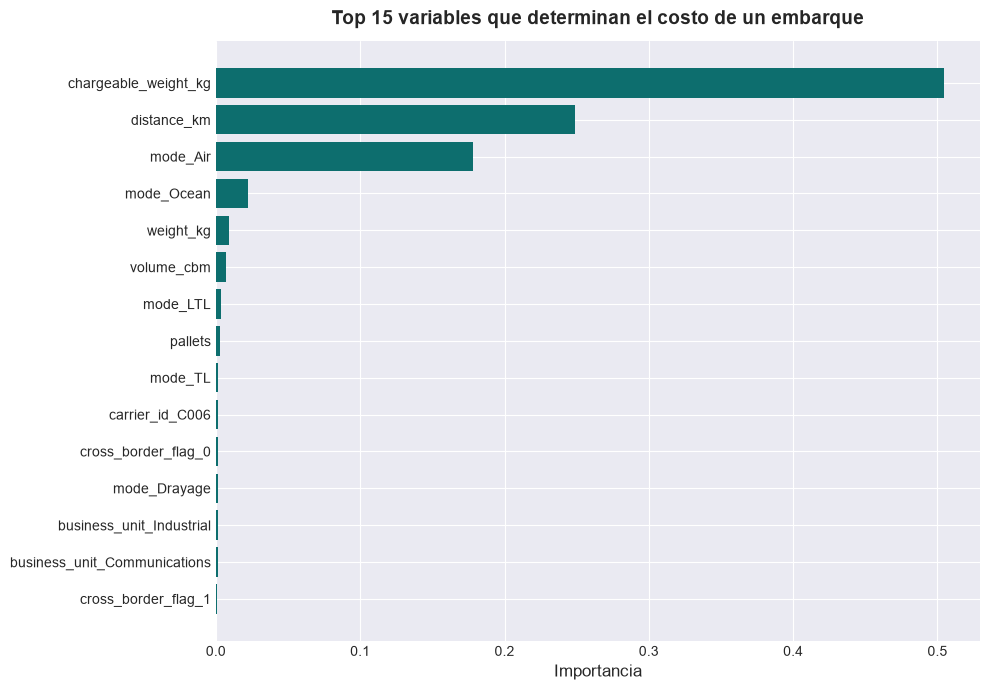

In [5]:
# ============================================================
# Importancia de variables del Random Forest
# ============================================================

# Extraer el modelo y el preprocesador del pipeline entrenado
regresor = modelo_rf.named_steps['regresor']
preproc = modelo_rf.named_steps['preprocesador']

# Obtener los nombres de todas las variables (incluyendo las categóricas ya codificadas)
# Las numéricas mantienen su nombre; las categóricas se expanden en varias columnas
nombres_num = features_num
nombres_cat = list(preproc.named_transformers_['cat'].get_feature_names_out(features_cat))
nombres_todas = nombres_num + nombres_cat

# Crear un dataframe con la importancia de cada variable
importancias = pd.DataFrame({
    'variable': nombres_todas,
    'importancia': regresor.feature_importances_
}).sort_values('importancia', ascending=False)

# Mostrar las 15 más importantes
print("TOP 15 variables más importantes para predecir el costo:")
print()
print(importancias.head(15).to_string(index=False))

# Graficar las top 15
plt.figure(figsize=(10, 7))
top15 = importancias.head(15)
plt.barh(top15['variable'], top15['importancia'], color='#0D6E6E')
plt.xlabel('Importancia', fontsize=12)
plt.title('Top 15 variables que determinan el costo de un embarque',
          fontsize=14, fontweight='bold', pad=12)
plt.gca().invert_yaxis()  # la más importante arriba
plt.tight_layout()
plt.show()

### Interpretación: los factores que determinan el costo

El modelo revela que **tres variables explican ~93% del costo** de un embarque:

| Variable | Importancia | Lectura de negocio |
|----------|-------------|--------------------|
| `chargeable_weight_kg` | 50.4% | El peso cobrable es el factor dominante: en logística se tarifa principalmente por peso. |
| `distance_km` | 24.9% | La distancia es el segundo driver: trayectos largos cuestan más. |
| `mode_Air` | 17.8% | El transporte **aéreo** encarece drásticamente el embarque frente a otros modos. |

**Hallazgos clave:**
- **Peso + distancia explican ~75%** del costo. Son las palancas físicas fundamentales.
- El **modo de transporte** (especialmente aéreo vs. marítimo/terrestre) es el tercer
  gran factor: cambiar de modo cuando sea viable es una palanca de ahorro directa.
- Variables como el **carrier específico, cross-border o unidad de negocio pesan poco**
  individualmente. Esto indica que el costo está gobernado por la física del embarque
  (peso, distancia, modo) más que por el proveedor.

**Implicación de negocio:** las estrategias de ahorro más efectivas deben enfocarse en
(1) optimización de peso/consolidación de carga, (2) optimización de rutas para reducir
distancia, y (3) evaluación de modo de transporte (¿es necesario el aéreo o puede ser
terrestre/marítimo?).

## 6. Detección de anomalías de costo

Esta es la aplicación de negocio más valiosa del modelo. La lógica es simple pero potente:

> Si el modelo predice que un embarque **debería** costar $X (basándose en su peso,
> distancia, modo, etc.), pero el costo **real** fue mucho mayor, ese embarque es una
> **anomalía**: pagó más de lo esperable para sus características.

**¿Cómo lo hacemos?**
1. Calculamos el **residual** = costo real − costo predicho, para cada embarque.
2. Los residuales muy positivos y grandes indican **sobrecostos** (pagamos de más).
3. Ordenamos y examinamos los casos más extremos.

**Valor:** esto convierte al modelo en un **sistema de auditoría automática de facturas**.
En lugar de revisar 219,000 embarques a mano, el modelo señala los pocos cientos que
merecen investigación. Conecta directamente con las oportunidades de ahorro del proyecto
(incluida la anomalía de carrier detectada en el análisis de negocio).

In [6]:
# ============================================================
# Detección de anomalías: costo real vs. costo predicho
# ============================================================

# Generar predicciones para TODO el dataset (no solo test)
# para poder auditar todos los embarques
pred_todos = modelo_rf.predict(X)

# Construir un dataframe de análisis con las columnas relevantes
analisis = df.copy()
analisis['costo_predicho'] = pred_todos
analisis['residual'] = analisis['total_cost_usd'] - analisis['costo_predicho']

# El % de sobrecosto: cuánto más caro fue lo real vs lo esperado
analisis['sobrecosto_pct'] = (analisis['residual'] / analisis['costo_predicho']) * 100

# Ordenar por residual descendente (los mayores sobrecostos primero)
anomalias = analisis.sort_values('residual', ascending=False)

# Mostrar las 10 anomalías más grandes (mayor sobrecosto absoluto)
print("TOP 10 ANOMALÍAS DE SOBRECOSTO (costo real >> costo esperado):")
print()
cols_mostrar = ['shipment_id', 'carrier_id', 'mode', 'distance_km',
                'chargeable_weight_kg', 'total_cost_usd', 'costo_predicho',
                'residual', 'sobrecosto_pct']
top_anomalias = anomalias[cols_mostrar].head(10).copy()

# Formatear para lectura
top_anomalias['total_cost_usd'] = top_anomalias['total_cost_usd'].apply(lambda x: f"${x:,.0f}")
top_anomalias['costo_predicho'] = top_anomalias['costo_predicho'].apply(lambda x: f"${x:,.0f}")
top_anomalias['residual'] = top_anomalias['residual'].apply(lambda x: f"${x:,.0f}")
top_anomalias['sobrecosto_pct'] = top_anomalias['sobrecosto_pct'].apply(lambda x: f"{x:,.0f}%")

print(top_anomalias.to_string(index=False))

TOP 10 ANOMALÍAS DE SOBRECOSTO (costo real >> costo esperado):

shipment_id carrier_id mode  distance_km  chargeable_weight_kg total_cost_usd costo_predicho residual sobrecosto_pct
 SHP1057124       C022  Air       3028.8                4488.8        $72,710        $52,677  $20,033            38%
 SHP1044523       C023  Air       4430.1                2919.9        $96,732        $79,425  $17,307            22%
 SHP1215169       C022  Air       4435.0                2110.2        $52,633        $38,122  $14,512            38%
 SHP1143183       C023  Air       4144.9                2040.1        $45,063        $30,946  $14,117            46%
 SHP1102678       C022  Air       1916.0                2965.6        $34,076        $20,625  $13,451            65%
 SHP1170165       C023  Air       2972.3                2679.0        $44,321        $31,340  $12,980            41%
 SHP1072198       C022  Air       3419.6                2190.1        $43,614        $31,981  $11,633            36%


### Interpretación: patrones en las anomalías

El análisis de las 10 mayores anomalías revela **patrones sistemáticos**, no casos aislados:

**1. Concentración en dos carriers (C022 y C023)**
8 de las 10 mayores anomalías corresponden a **C022 y C023**. Esto sugiere que estos
carriers cobran de forma consistente por encima de lo esperable para las características
de sus embarques. Amerita una **auditoría de tarifas y renegociación**.

**2. Predominancia del modo aéreo**
9 de 10 anomalías son transporte **aéreo (Air)**. Los sobrecostos se concentran en
envíos aéreos, lo que refuerza la recomendación de evaluar si todos esos envíos
requieren realmente ese modo (el más caro).

**3. Caso crítico de sobrecosto relativo**
El embarque `SHP1101202` (carrier C009, modo LTL) pagó **$21,174 frente a ~$10,113
esperados: un sobrecosto del 109%**, más del doble de lo previsible. Requiere revisión
inmediata de su facturación.

**Impacto económico:**
Solo estas 10 anomalías suman ~$130,000 USD en sobrecostos. Extendido a todo el universo
de embarques con desviaciones significativas, esto conecta directamente con las
oportunidades de ahorro cuantificadas en el análisis de negocio del proyecto.

**Valor del método:** el modelo permite pasar de auditar 219,120 embarques manualmente
a enfocar la atención en los pocos cientos con mayor desviación, priorizados por impacto
económico.

## Visualización de resultados del modelo

Complementamos el análisis con dos visualizaciones estándar para evaluar un modelo
de regresión:

1. **Predicho vs. Real:** compara lo que el modelo predijo contra el valor real. Si el
   modelo fuera perfecto, todos los puntos caerían sobre la línea diagonal. Qué tan
   cerca estén de esa línea muestra visualmente la calidad del modelo.

2. **Distribución de residuales:** los residuales (real − predicho) deberían centrarse
   en cero y distribuirse simétricamente. La cola positiva (residuales grandes) es donde
   viven las anomalías de sobrecosto.

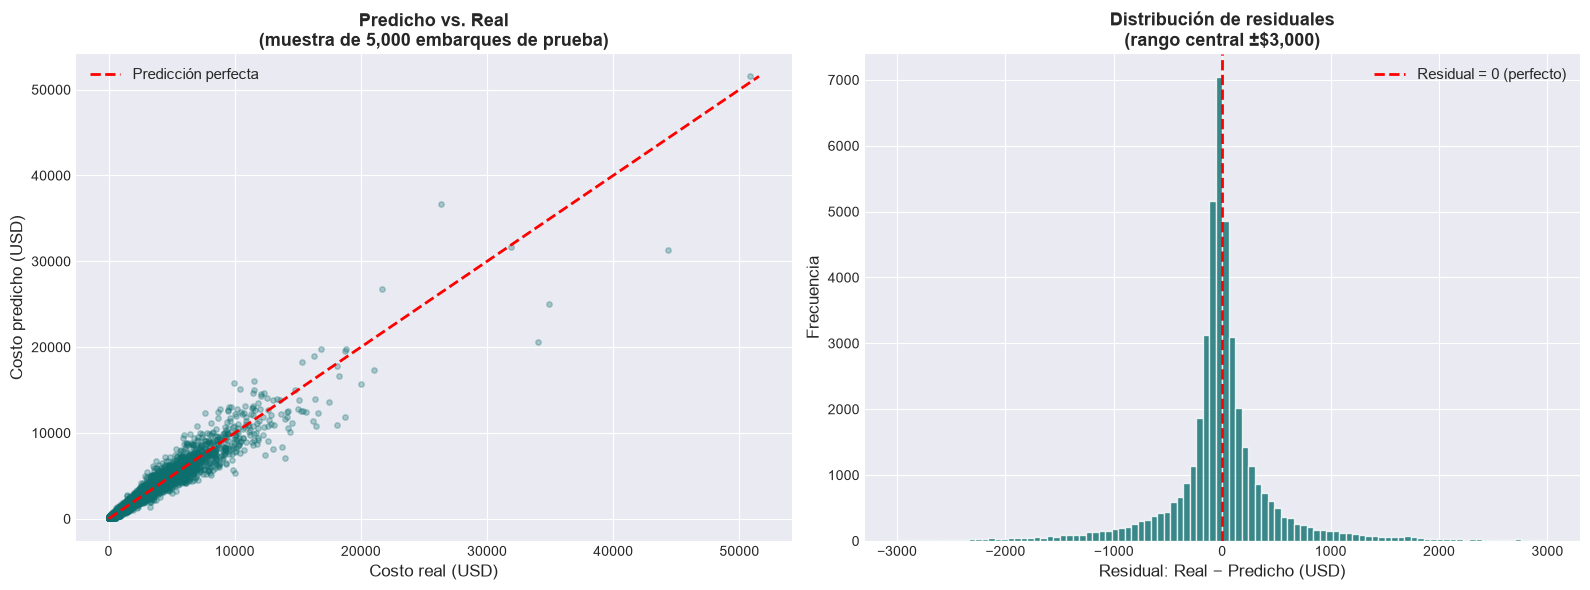

✓ Visualizaciones generadas
✓ Residual promedio: $-10.48 USD (idealmente cercano a 0)
✓ Mediana del residual: $-30.04 USD


In [7]:
# ============================================================
# Visualizaciones de desempeño del modelo
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---- Gráfica 1: Predicho vs Real ----
# Usamos una muestra de 5000 puntos del conjunto de prueba para que la gráfica
# no se sature (43,824 puntos serían demasiados para visualizar bien)
muestra_idx = np.random.RandomState(42).choice(len(y_test), size=5000, replace=False)
y_test_muestra = y_test.iloc[muestra_idx]
pred_muestra = pred_rf[muestra_idx]

axes[0].scatter(y_test_muestra, pred_muestra, alpha=0.3, s=15, color='#0D6E6E')

# Línea diagonal de predicción perfecta (y = x)
lim_max = max(y_test_muestra.max(), pred_muestra.max())
axes[0].plot([0, lim_max], [0, lim_max], 'r--', linewidth=2, label='Predicción perfecta')

axes[0].set_xlabel('Costo real (USD)', fontsize=12)
axes[0].set_ylabel('Costo predicho (USD)', fontsize=12)
axes[0].set_title('Predicho vs. Real\n(muestra de 5,000 embarques de prueba)',
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)

# ---- Gráfica 2: Distribución de residuales ----
residuales_test = y_test - pred_rf

# Limitamos el rango del eje x para ver bien el centro de la distribución
# (los outliers extremos harían ilegible el histograma)
axes[1].hist(residuales_test, bins=100, range=(-3000, 3000),
             color='#0D6E6E', edgecolor='white', alpha=0.8)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Residual = 0 (perfecto)')

axes[1].set_xlabel('Residual: Real − Predicho (USD)', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)
axes[1].set_title('Distribución de residuales\n(rango central ±$3,000)',
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print("✓ Visualizaciones generadas")
print(f"✓ Residual promedio: ${residuales_test.mean():,.2f} USD (idealmente cercano a 0)")
print(f"✓ Mediana del residual: ${residuales_test.median():,.2f} USD")

### Interpretación de las visualizaciones

**Predicho vs. Real (gráfica izquierda):**
La mayoría de los puntos se alinean estrechamente sobre la diagonal de predicción
perfecta, confirmando visualmente el alto R² (0.9418). Los embarques de costo bajo y
medio se predicen con gran precisión. La dispersión aumenta ligeramente en los embarques
más caros (>$20,000), que son menos frecuentes y más difíciles de modelar — un
comportamiento esperado y aceptable.

**Distribución de residuales (gráfica derecha):**
Los residuales forman una campana centrada en cero, indicando que el modelo **no está
sesgado** (no sobreestima ni subestima sistemáticamente). El residual promedio (-$10.48)
y la mediana (-$30.04) son prácticamente nulos, lo que valida la calidad del ajuste.

**Detalle relevante:** la cola derecha (residuales positivos) es ligeramente más larga.
Esta asimetría es precisamente la evidencia de los **sobrecostos**: embarques que costaron
más de lo que sus características predicen, es decir, las anomalías identificadas en la
sección anterior.

## 8. Conclusiones de negocio

### Resumen del análisis
Se construyó un modelo de **Random Forest** que predice el costo de un embarque con
**94.2% de precisión (R²)** y un error promedio de **$341 USD**. Las visualizaciones
confirmaron un ajuste sólido (puntos alineados sobre la diagonal, residuales centrados
en cero). El modelo no solo predice: se convierte en una **herramienta de auditoría**
que detecta sobrecostos comparando el costo real contra el esperado.

### Hallazgos clave

| Hallazgo | Detalle |
|----------|---------|
| Mejor modelo | Random Forest (R² = 0.9418) vs. Regresión Lineal (R² = -5.94) |
| Error promedio | 341 USD sobre costo medio de 2,120 USD (aprox 16%) |
| Factores dominantes | Peso cobrable (50%), distancia (25%), modo aéreo (18%) |
| Carriers con anomalías | C022 y C023 concentran los mayores sobrecostos |
| Caso crítico | SHP1101202: 109% de sobrecosto (\$21,174 vs. \$10,113 esperado) |

### Valor para el negocio

**1. Auditoría automática de facturas.**
En lugar de revisar 219,120 embarques manualmente, el modelo prioriza los pocos cientos
con mayor desviación de costo, ordenados por impacto económico. Esto hace viable una
auditoría sistemática que antes era imposible por volumen.

**2. Identificación de carriers a renegociar.**
La concentración de anomalías en C022 y C023 entrega una lista concreta y respaldada en
datos para renegociar tarifas o revisar contratos.

**3. Herramienta de cotización.**
El modelo puede estimar el costo esperado de un embarque nuevo antes de contratarlo,
sirviendo como referencia para validar cotizaciones de proveedores.

**4. Palancas de ahorro accionables.**
El análisis de importancia señala dónde enfocar esfuerzos: consolidación de carga
(peso), optimización de rutas (distancia) y evaluación de modo de transporte
(¿aéreo realmente necesario?).

### Limitaciones y siguientes pasos
- El modelo detecta desviaciones estadísticas, pero **cada anomalía debe validarse
  manualmente**: un sobrecosto puede tener justificación legítima (urgencia, zona remota,
  mercancía especial) no capturada en las variables.
- Se recomienda **re-entrenar periódicamente** conforme cambian las tarifas del mercado.
- **Siguiente módulo:** clasificación de embarques en riesgo de retraso, para anticipar
  problemas de servicio antes de que ocurran.

---
*Módulo 2 completado. Modelo entrenado, evaluado, interpretado y aplicado a un caso de negocio real.*

In [8]:
# ============================================================
# EXPORTAR RESULTADOS PARA EL DASHBOARD
# ============================================================
import os
import json

carpeta_dash = '../dashboard/data_ml'
os.makedirs(carpeta_dash, exist_ok=True)

# 1. Comparación de modelos (lineal vs random forest)
comparacion_m2 = pd.DataFrame({
    'modelo': ['Regresión Lineal', 'Random Forest'],
    'mae': [round(mae_lineal, 2), round(mae_rf, 2)],
    'rmse': [round(rmse_lineal, 2), round(rmse_rf, 2)],
    'r2': [round(r2_lineal, 4), round(r2_rf, 4)]
})
comparacion_m2.to_csv(f'{carpeta_dash}/m2_comparacion_modelos.csv', index=False)

# 2. Importancia de variables (top 15)
importancias.head(15).to_csv(f'{carpeta_dash}/m2_importancia_variables.csv', index=False)

# 3. Top anomalías de sobrecosto (las 20 mayores)
cols_anom = ['shipment_id', 'carrier_id', 'mode', 'distance_km',
             'chargeable_weight_kg', 'total_cost_usd', 'costo_predicho',
             'residual', 'sobrecosto_pct']
anomalias[cols_anom].head(20).to_csv(f'{carpeta_dash}/m2_anomalias.csv', index=False)

# 4. Muestra para el scatter predicho vs real (5000 puntos)
muestra_scatter = pd.DataFrame({
    'costo_real': y_test.iloc[muestra_idx].values,
    'costo_predicho': pred_rf[muestra_idx]
})
muestra_scatter.to_csv(f'{carpeta_dash}/m2_scatter.csv', index=False)

# 5. Métricas clave
metricas_m2 = {
    'r2_rf': round(r2_rf, 4),
    'mae_rf': round(mae_rf, 2),
    'rmse_rf': round(rmse_rf, 2),
    'top_variable': importancias.iloc[0]['variable'],
    'top_variable_pct': round(importancias.iloc[0]['importancia'] * 100, 1),
    'n_embarques': len(df)
}
with open(f'{carpeta_dash}/m2_metricas.json', 'w', encoding='utf-8') as f:
    json.dump(metricas_m2, f, indent=2, ensure_ascii=False)

print("✓ Resultados del Módulo 2 exportados a dashboard/data_ml/")
print("  - m2_comparacion_modelos.csv")
print("  - m2_importancia_variables.csv")
print("  - m2_anomalias.csv")
print("  - m2_scatter.csv")
print("  - m2_metricas.json")

✓ Resultados del Módulo 2 exportados a dashboard/data_ml/
  - m2_comparacion_modelos.csv
  - m2_importancia_variables.csv
  - m2_anomalias.csv
  - m2_scatter.csv
  - m2_metricas.json
